# 00 · Setup, data and the baseline model

*Environment, Voicebank-DEMAND, and what CRNTiny actually is*

Neural Audio and Speech Processing — Day 2 / Application to Speech Enhancement
Homework assignment, R. Scheibler (2026-07-02) · dataset: Voicebank-DEMAND (16 kHz)

## The assignment

> **Task**: implement and evaluate modifications to a speech enhancement baseline
> using the nanoSE framework. **Deliverable**: a one-page report generated with
> `create_report.py`, comparing a baseline run against your own experiment.

The five suggested project ideas are covered by the notebooks in this folder:

| Notebook | Assignment task |
|---|---|
| `00_setup_and_data.ipynb` | environment, dataset, model — no training |
| `01_baseline.ipynb` | the reference baseline run (`config/default_config.py`) |
| `02_activation_study.ipynb` | **Task 1** — activation function in `EncoderBlock` / `DecoderBlock` |
| `03_lr_tuning.ipynb` | **Task 2** — tune the step size `lr` |
| `04_speed_and_single_epoch.ipynb` | **Tasks 3 & 4** — best SI-SDR per unit of time, best single epoch |
| `05_final_experiment_and_report.ipynb` | **Task 5** — own idea + the report deliverable |

Run them in order: `01` produces the baseline every later notebook compares against.

## Hardware

Training is only practical on a GPU. On a T4 (Colab) a 25-epoch CRNTiny run takes
roughly 45–70 min; on 4 CPU threads the same run takes **more than 15 hours**
(measured: ~3–5 s per batch-32 step, 528 steps per epoch). Use
*Runtime > Change runtime type > T4 GPU*.

In [1]:
# --- Google Colab bootstrap (does nothing when running locally) --------------
# IMPORTANT: point this at the fork that contains the homework modifications
# (models/crn.py with a selectable activation, train.py with --warmup-steps).
REPO_URL = "https://github.com/Ahmed-AlGhosaini/nanoSE.git"

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import os

    if not os.path.exists("nanoSE"):
        !git clone -q $REPO_URL nanoSE
    %cd nanoSE
    !pip install -q -r requirements.txt

    import torch
    if not torch.cuda.is_available():
        print("No GPU! Runtime > Change runtime type > T4 GPU, then re-run this cell.")

/content/nanoSE
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 79.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 57.9 MB/s eta 0:00:00


In [2]:
import sys
from pathlib import Path

# Make notebooks/nb_utils.py importable no matter where the kernel was started
for candidate in (Path.cwd(), Path.cwd() / "notebooks", Path.cwd().parent / "notebooks"):
    if (candidate / "nb_utils.py").exists():
        sys.path.insert(0, str(candidate))
        break

import matplotlib.pyplot as plt
import pandas as pd

import nb_utils

ROOT = nb_utils.bootstrap()   # chdir to the repository root + print the device

Repository root: /content/nanoSE
torch 2.11.0+cu128 | CUDA GPU: Tesla T4 (15.6 GB)


## 1. Environment

`nb_utils.bootstrap()` already printed the device. The training script picks the
device itself in this order: CUDA → Apple MPS → CPU, and on a GPU it preloads the
whole dataset into GPU memory (see `dataset.py`), which is why the data loader
never becomes the bottleneck.

In [3]:
import torch

print(nb_utils.describe_device())
print("Float32 matmul precision :", torch.get_float32_matmul_precision())
print("CPU threads              :", torch.get_num_threads())

torch 2.11.0+cu128 | CUDA GPU: Tesla T4 (15.6 GB)
Float32 matmul precision : highest
CPU threads              : 1


## 2. The Voicebank-DEMAND dataset

Clean speech (Voicebank) mixed with everyday noise (DEMAND: office, cafe, street,
bus, …). `dataset.py` caches the whole corpus as raw interleaved `int16`
(`train_cache.bin` ≈ 2.2 GB, `test_cache.bin` ≈ 130 MB); the **first** call below
downloads and builds those caches, later calls are instant.

* **train** — cut into fixed 2 s segments (32 000 samples), used with `batch_size=32`
* **test** — full-length utterances, one per batch, used for validation

In [4]:
from dataset import VoiceBankDemandDataset

train_ds = VoiceBankDemandDataset(split="train")   # first call: downloads + caches
test_ds = VoiceBankDemandDataset(split="test")

noisy, clean = train_ds[0]
print(f"train segments : {len(train_ds):>6}  ({len(train_ds) * 2 / 3600:.1f} h of audio, 2 s each)")
print(f"test utterances: {len(test_ds):>6}")
print(f"segment shape  : {tuple(noisy.shape)}  dtype {noisy.dtype}")
print(f"steps / epoch  : {len(train_ds) // 32}  at batch_size=32")

Cache file train_cache.bin not found. Loading split 'train' of JacobLinCool/VoiceBank-DEMAND-16k...


README.md:   0%|          | 0.00/652 [00:00<?, ?B/s]

data/train-00000-of-00005.parquet: reconstructing file:   0%|          |  0.00B /  444MB            

data/train-00000-of-00005.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00005.parquet: reconstructing file:   0%|          |  0.00B /  416MB            

...

Caching train: 100%|██████████| 11572/11572 [03:36<00:00, 53.57it/s]


Saving training dataset cache to train_cache.bin...
Loaded 16904 cached segments of length 32000.
Cache file test_cache.bin not found. Loading split 'test' of JacobLinCool/VoiceBank-DEMAND-16k...
Caching dataset to memory and writing cache to test_cache.bin...


Caching test: 100%|██████████| 824/824 [00:13<00:00, 60.77it/s]


Successfully cached 824 samples to test_cache.bin.
train segments :  16904  (9.4 h of audio, 2 s each)
test utterances:    824
segment shape  : (32000,)  dtype torch.float32
steps / epoch  : 528  at batch_size=32


/content/nanoSE/dataset.py:182: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  noisy_f32 = torch.from_numpy(noisy_int16).to(torch.float32) / 32767.0


### Input SNR — how hard is the task?

The noise signal is recoverable exactly, because the dataset ships the clean and
noisy version of the *same* utterance: `noise = noisy - clean`.

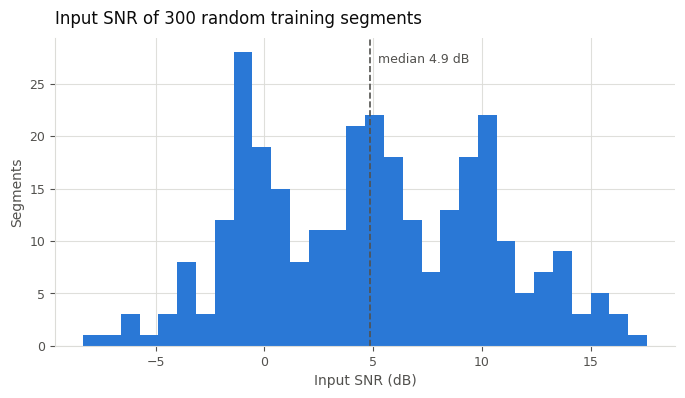

input SNR: median 4.9 dB, 10th pct -1.6 dB, 90th pct 12.2 dB


In [5]:
import numpy as np

rng = np.random.default_rng(0)
indices = rng.choice(len(train_ds), size=300, replace=False)

snr_db = []
for i in indices:
    noisy_i, clean_i = train_ds[int(i)]
    noise_i = noisy_i - clean_i
    snr_db.append(
        10 * torch.log10((clean_i.pow(2).sum() + 1e-12) / (noise_i.pow(2).sum() + 1e-12)).item()
    )
snr_db = np.array(snr_db)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(snr_db, bins=30, color=nb_utils.PALETTE[0])
ax.axvline(np.median(snr_db), color=nb_utils.INK_SOFT, linewidth=1.2, linestyle="--")
ax.annotate(
    f"median {np.median(snr_db):.1f} dB",
    (np.median(snr_db), ax.get_ylim()[1] * 0.92),
    xytext=(6, 0), textcoords="offset points", color=nb_utils.INK_SOFT, fontsize=9,
)
nb_utils.style_axes(ax, "Input SNR of 300 random training segments", "Input SNR (dB)", "Segments")
plt.show()

print(f"input SNR: median {np.median(snr_db):.1f} dB, 10th pct {np.percentile(snr_db, 10):.1f} dB, "
      f"90th pct {np.percentile(snr_db, 90):.1f} dB")

### What the model sees

The model never touches the waveform directly: it predicts a **mask** on the
magnitude spectrogram (512-point STFT, hop 256 → 257 bins, of which the Nyquist
bin is dropped to get the 256 bins the convolutional encoder needs), then the
noisy phase is reused to resynthesise the waveform.

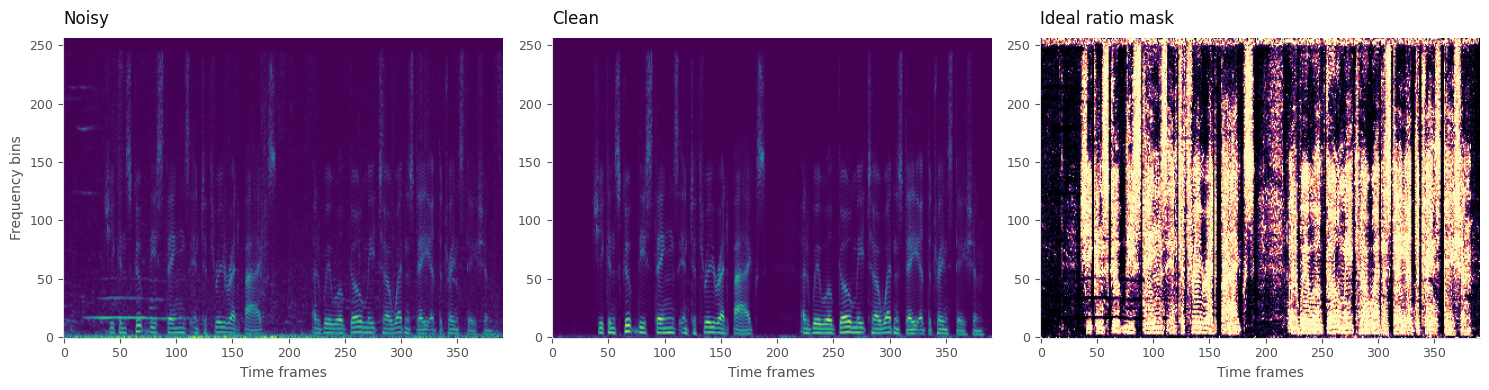

In [6]:
from model import waveform_to_spectrogram

example = 3
noisy_e, clean_e = test_ds[example]

specs = {
    "Noisy": torch.abs(waveform_to_spectrogram(noisy_e.unsqueeze(0)))[0],
    "Clean": torch.abs(waveform_to_spectrogram(clean_e.unsqueeze(0)))[0],
    "Ideal ratio mask": None,
}
eps = 1e-8
specs["Ideal ratio mask"] = specs["Clean"] / (specs["Noisy"] + eps)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (title, spec) in zip(axes, specs.items()):
    data = spec.clamp(0, 1).numpy() if "mask" in title else np.log1p(spec.numpy())
    ax.imshow(data, aspect="auto", origin="lower", cmap="magma" if "mask" in title else "viridis")
    nb_utils.style_axes(ax, title, "Time frames", "Frequency bins" if ax is axes[0] else "")
    ax.grid(False)
plt.tight_layout()
plt.show()

In [7]:
from IPython.display import Audio, display

print("Noisy input:")
display(Audio(noisy_e.numpy(), rate=16000))
print("Clean target:")
display(Audio(clean_e.numpy(), rate=16000))

Noisy input:


Clean target:


## 3. The baseline model — `CRNTiny`

A convolutional recurrent network: a 4-stage strided-conv encoder (256 → 16
frequency bins, 4 → 32 channels), a single-layer GRU bottleneck over time, and a
mirrored transposed-conv decoder with skip connections, ending in a `sigmoid`
mask.

Both `EncoderBlock` and `DecoderBlock` are `conv → BatchNorm → activation`, and the
activation is the knob Task 1 asks about.

In [8]:
from models.crn import CRN, CRNTiny, ACTIVATIONS

tiny, big = CRNTiny(), CRN()
print(f"CRNTiny : {sum(p.numel() for p in tiny.parameters()):>9,} parameters")
print(f"CRN     : {sum(p.numel() for p in big.parameters()):>9,} parameters")
print(f"\nDefault block: {tiny.enc1.conv} -> {tiny.enc1.bn} -> {tiny.enc1.act}")
print(f"\nSelectable activations: {sorted(ACTIVATIONS)}")

rows = [
    {"module": name, "parameters": sum(p.numel() for p in mod.parameters())}
    for name, mod in tiny.named_children()
]
pd.DataFrame(rows).assign(share=lambda d: (d.parameters / d.parameters.sum() * 100).round(1))

CRNTiny :   174,941 parameters
CRN     : 1,738,809 parameters

Default block: Conv2d(1, 4, kernel_size=(5, 3), stride=(2, 1), padding=(2, 1)) -> BatchNorm2d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True) -> LeakyReLU(negative_slope=0.2)

Selectable activations: ['elu', 'gelu', 'hardswish', 'leaky_relu', 'mish', 'prelu', 'relu', 'silu', 'tanh']


,module,parameters,share
0,enc1,72,0.0
1,enc2,504,0.3
2,enc3,1968,1.1
3,enc4,7776,4.4
4,gru,110976,63.4
5,linear,33280,19.0
6,dec4,15408,8.8
7,dec3,3864,2.2
8,dec2,972,0.6
9,dec1_deconv,121,0.1


### Loss

`CRNTiny.compute_loss` combines a magnitude-spectrogram MSE with a waveform
SI-SDR term: `loss = spec_weight · MSE + sdr_weight · (−SI-SDR)` with
`spec_weight=1.0`, `sdr_weight=0.01` in the baseline. The two terms live on very
different scales — the MSE is ~1e-2 while the SI-SDR term is ~−10 — so the
effective weighting is something Task 5 can revisit.

### Throughput on this machine

In [9]:
import time

model = CRNTiny().to("cuda" if torch.cuda.is_available() else "cpu")
device = next(model.parameters()).device
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

batch = 32
noisy_b = torch.randn(batch, 32000, device=device) * 0.05
clean_b = torch.randn(batch, 32000, device=device) * 0.05

for _ in range(3):                                   # warm up
    _, loss, _ = model.compute_loss(noisy_b, clean_b)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
if device.type == "cuda":
    torch.cuda.synchronize()

start = time.time()
n_steps = 10
for _ in range(n_steps):
    _, loss, _ = model.compute_loss(noisy_b, clean_b)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
if device.type == "cuda":
    torch.cuda.synchronize()
step_time = (time.time() - start) / n_steps

steps_per_epoch = len(train_ds) // batch
print(f"device            : {device}")
print(f"step time         : {step_time * 1000:.0f} ms  ({batch / step_time:.0f} segments/s)")
print(f"training / epoch  : {steps_per_epoch * step_time / 60:.1f} min ({steps_per_epoch} steps)")
print(f"25 epochs         : {25 * steps_per_epoch * step_time / 60:.0f} min of training "
      "(+ validation, which is dominated by PESQ/DNSMOS on CPU)")

device            : cuda:0
step time         : 53 ms  (599 segments/s)
training / epoch  : 0.5 min (528 steps)
25 epochs         : 12 min of training (+ validation, which is dominated by PESQ/DNSMOS on CPU)


## Takeaways

* ~2.9 h of 2 s training segments, median input SNR around 8–9 dB.
* `CRNTiny` has ~175 k parameters — small enough that a full 25-epoch run fits in
  one Colab session, which is what makes a *sweep* over activations and learning
  rates possible at all.
* Validation is not free: PESQ, eSTOI and DNSMOS run on CPU for 20 utterances at
  every epoch, and SI-SDR is computed over all 824 test files. Expect roughly a
  minute of validation per epoch on top of the training time.

**Next:** `01_baseline.ipynb` trains the reference run.